In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
def euler_generalizado(y0,h,ti,tf,f,m):
    N = int(np.ceil((tf - ti) / h))
    t = np.zeros(N + 1)
    U = np.zeros(shape = (m, N + 1))
    t[0] = ti
    U[:, 0] = y0
    for i in range(N):
        U[:, i + 1] = U[:, i] + h*f(t[i], U[:,i])
        t[i + 1] = t[i] + h
    return t,U

def runge_kutta_generalizado(y0,h,ti,tf,f,m):
    N = int(np.ceil((tf - ti) / h))
    t = np.zeros(N + 1)
    U = np.zeros(shape = (m, N + 1))
    t[0] = ti
    U[:, 0] = y0
    k1 = np.zeros(m)
    k2 = np.zeros(m)
    k3 = np.zeros(m)
    k4 = np.zeros(m)

    for i in range(N):
        k1 = f(t[i],U[:,i])
        k2= f(t[i] + h/2, U[:, i] + (h/2)*k1)
        k3 = f(t[i] + h/2,U[:, i] + (h/2)*k2)
        k4 = f(t[i] + h,U[:, i] + h*k3)
        U[:,i + 1] = U[:, i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t[i + 1] = t[i] + h
    return t,U

In [22]:
def F(t,U):
    x,y = U[0], U[1]
    eqs = np.array([x - 0.1*x*y, -1.5*y + 0.075*x*y])
    return eqs
y0 = [10,5]

In [23]:
t, y_rk = runge_kutta_generalizado(y0, 0.1, 0, 30, F,2)
t, y_euler = euler_generalizado(y0, 0.1, 0, 30, F,2)

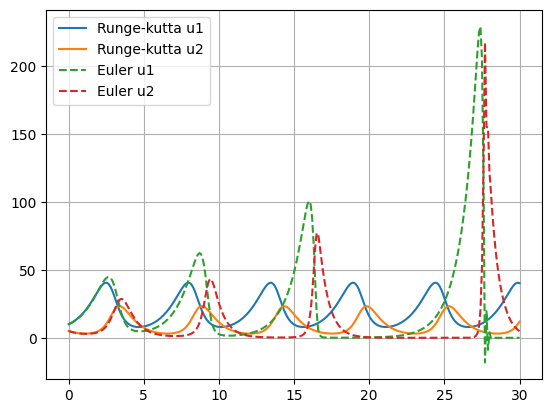

In [24]:
for i in range(len(y_rk)):
    plt.plot(t,y_rk[i], label = f"Runge-kutta u{i + 1}")
for i in range(len(y_euler)):
    plt.plot(t,y_euler[i], label = f"Euler u{i + 1}", linestyle = '--')
plt.grid()
plt.legend()
plt.show()

In [25]:
def F(t,U):
    u1 , u2 = U[0], U[1]
    eqs = np.array([u2, np.exp(2*t)*np.sin(t) + 2*u2 - 2*u1])
    return eqs

t,y_euler = euler_generalizado([-0.4,-0.6],0.1,0,1,F,2)
t,y_rk = runge_kutta_generalizado([-0.4,-0.6],0.1,0,1,F,2)

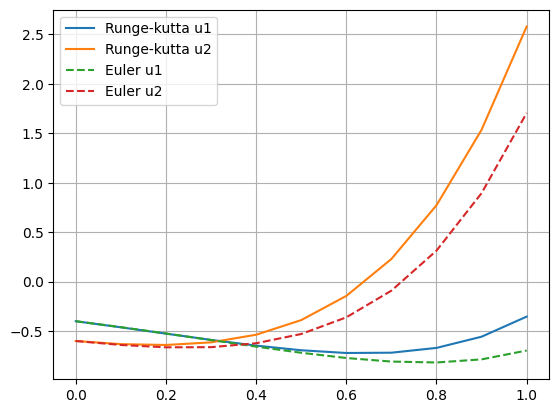

In [26]:
for i in range(len(y_rk)):
    plt.plot(t,y_rk[i], label = f"Runge-kutta u{i + 1}")
for i in range(len(y_euler)):
    plt.plot(t,y_euler[i], label = f"Euler u{i + 1}", linestyle = '--')
plt.grid()
plt.legend()
plt.show()

Exercício 1

In [44]:
def F(t,U):
    x,y = U[0], U[1]
    eqs = np.array([y,(2/t)*y - (2/(t**2))*x + t*np.log(t)])
    return eqs

def real_f(t):
    return (7/4)*t + (1/2)*t**3 * np.log(t) - (3/4)*t**3
y0 = [1,0]

In [49]:
t,y = runge_kutta_generalizado(y0,0.1,1,2,F,2)

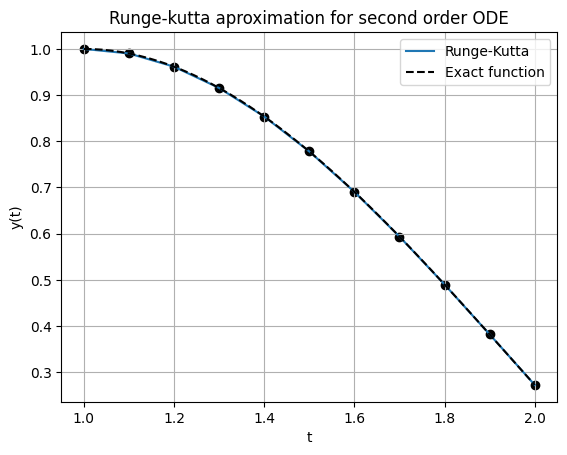

In [53]:
plt.plot(t,y[0], label = "Runge-Kutta")
plt.scatter(t,y[0], color = 'black')
plt.plot(np.linspace(1,2),real_f(np.linspace(1,2)), label = "Exact function", linestyle = '--', color = 'black')
plt.title("Runge-kutta aproximation for second order ODE")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid()
plt.legend()
plt.show()